<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E6%BC%94%E7%BF%92_2_%E7%94%BB%E7%B4%A0%E3%81%AE%E6%BF%83%E6%B7%A1%E5%A4%89%E6%8F%9B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
デジタル画像処理演習

# **画素の濃淡変換**

2026/04/27 改訂

---

この演習では、画素の濃淡変換に関して以下の内容を学習します。

1. 明るさの変換
1. トーンカーブ
1. 色の変換
1. 色空間の変換
1. ヒストグラム平坦化

次に書かれている「準備」から順番に進めていってください。  

<a name="junbi"></a>
# **準備**

最初に準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
from google.colab.patches import cv2_imshow
from ipywidgets import interact, interactive, IntSlider, FloatSlider
from IPython.display import display

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# Matplotlibの設定
plot_config = {'xticks': np.arange(0, 257, 64), 'yticks': np.arange(0, 257, 64), 'xlabel': 'Input', 'ylabel': 'Output', 'xlim': (0, 256), 'ylim': (0, 256)}

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imagefiles.zip" -O imagefiles.zip
!unzip -nq imagefiles.zip
!rm -f imagefiles.zip
!if [[ -f "asagao.png" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されれば成功です。
次のライブラリや関数が使えるようになっています。

|名称|説明|
|:---|:---|
|cv2|画像処理ライブラリ OpenCV|
|np|数値計算ライブラリ NumPy|
|plt|グラフ描画ライブラリ Matplotlib|
|cv2_imshow|Colab専用の画像表示関数|

画像ファイルも用意されています。Colab の画面の左端にある「ファイル」アイコン（📁の形）をクリックするとファイルブラウザが表示されて、ファイルの一覧を見ることができます。もう一度クリックすると非表示になります。  
自分のパソコンに保存してある画像ファイルを Colab で使いたい場合には、このファイルブラウザの中へ画像ファイルをドラッグ＆ドロップしてください。

<br>


# **1．明るさの変換**

画像は、画素値の大きさによって画像の明るさが決まります。つまり、全画素の画素値を増やしたり減らしたりすれば、画像全体の明るさが変化します。

まずは、この明るさの変換からやってみましょう。

##画素値の計算

はじめに、画像の読み込みます。
ここでは、画像ファイル`asagao.png`を読み込んで、変数`src`に記憶します。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像ファイルの読み込み
src = cv2.imread('asagao.png').astype(float) # astypeを使って画素値を実数型(float)に変える
show_image(src)

朝顔の花の画像が表示されましたか？  
画素値の計算では実数値を使うので、このコードでは、`cv2.imread`関数で読み込んだ画像データを、`astype(float)`によって整数型から実数型に変換しています。ここは今は理解できなくても大丈夫です。

画像が格納されている変数に四則演算（加算`+`、減算`-`、乗算`*`、除算`/`）を使用すると、全画素の画素値に対して演算が実行されます。
試しに、全画素の画素値に 80 を加えてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像を明るくする
dst = src + 80
show_image(dst)

画像が明るくなりましたね。

`src + 80`で全画素に 80 が加えられた新しい画像がつくられます。この新しい画像を代入式 `=` で、変数`dst`に記憶させています。
そして、`show_image`関数で変数`dst`の画像を表示しています。

今度は明るさを $\frac{1}{2}$ にしてみましょう。

In [ ]:
#@title ⌨ 画像を暗くする
dst = src / 2
show_image(dst)

画像が暗くなりました。

このように、計算式によって画像の変換を行うことができます。

### ✍ 実践問題 1

次の実践問題用コードを実行して、もとの画像を表示しましょう。  
その後で、コードの3行目の計算式を次のように書き替えて、画像の明るさを変えてみましょう。
1. 明るさを $2$ 倍にしてみよう。
1. 明るさを $\frac{2}{3}$ 倍にしてみよう。
1. もとの画素値を$x$とするとき、明るさを $\frac{x}{2}+128$ で計算してみよう。
1. 画像のネガポジ反転（明るさの反転）をしてみよう。

<details><summary>答え（←クリックすると開きます）</summary>

1. `dst = src * 2`
1. `dst = src * 2 / 3`
1. `dst = src / 2 + 128`
1. `dst = 255 - src`

</details>

In [ ]:
#@title ⌨ 実践問題用コード 1
src = cv2.imread('asagao.png').astype(float)
dst = src         # この行のコードを書き変える
show_image(dst)

明るさを2倍にもしてしまうと、明るすぎて真っ白になり細部が分からなくなりますね。これを画像の白飛びと言います。

これは、新しい画素値が画素値の上限である 255 を超えてしまうことで起こります。


## ガンマ補正

画像の白飛びを起こさない明るさ変換の方法に、ガンマ補正があります。

ガンマ補正とは、画像を明るさを非線形に変換する処理です。次のような計算式になります。

$$y=255\left(\frac{x}{255}\right)^\frac{1}{\gamma}$$

$x$は変換前の画素値（$0\leqq x\leqq 255$）、$y$は変換後の画素値（$0\leqq y\leqq 255$）です。  
$\gamma$（ガンマ）は明るさを調整するためのパラメータです。

この計算をプログラムにすると次のようになります。3行目にある`**`はべき乗の演算子です。例えば、$a^2$の場合は`a**2`と書き表します。  
コードを実行してみましょう。

In [ ]:
#@title ⌨ ガンマ補正で画像を明るくする
gamma = 5.0                    # ɤの値を設定する
src = cv2.imread('asagao.png').astype(float)
dst = 255*(src/255)**(1/gamma) # srcの画像に対してガンマ補正を行い、変換後画像をdstに記憶する
show_image(dst)

$\gamma$ の値を $5.0$ にした場合の結果です。だいぶ明るいですが、白飛びはほとんど起きていませんね。

### ✍ 実践問題 2

$\gamma$ の値による画像の明るさの変化を観察してみましょう。

次のコードを実行すると、$\gamma$ の値を調整するスライダーが表示されます。  
画像は2つ表示されます。左側が変換後の画像、右側がもとの画像です。

スライダーを動かして、明るさが変わる様子を見てください。

1. もとの画像と同じ明るさになるときの $\gamma$ の値はいくつですか？
1. 極端に明るくすると、花の部分がオレンジ色から黄色になります。これはなぜですか？
1. 極端に暗くすると、花の部分がオレンジ色から赤色になります。これはなぜですか？

ヒント　標準的な<font color="#ffa500">■</font>オレンジ色のRGBの値は、赤=255、緑=165、青=0 です。

<details><summary>答え</summary>

1. $\gamma=1$のとき。
1. ガンマ補正では、もとの画素値が 0 であれば、変換後の画素値も 0 になります。オレンジ色の部分を極端に明るくすると、赤チャンネルと緑チャンネルの画素値はほぼ最大値の 255 になりますが、青チャンネルの画素値は 0 に近いままです。したがって、黄色になって表示されます。
1. 上とは反対に、ガンマ補正では、もとの画素値が 255 であれば、変換後の画素値も 255 になります。オレンジ色を極端に暗くすると、赤チャンネルは 255 に近いままですが、緑チャンネルと青チャンネルはほぼ 0 になります。したがって、赤色になって表示されます。

</summary>



In [ ]:
#@title ⌨ 実践問題用コード 2
src = cv2.imread('saboten.jpg').astype(float)

@interact(gamma = FloatSlider(min=0.1, max=8.0, step=0.1, value=2.0, description='Gamma')) # スライダの設定
def transform_image(gamma):
  dst = 255*(src/255)**(1/gamma)
  show_image(np.concatenate([dst, src], 1)) # 左にdstの画像、右にsrcの画像を表示する

<br>

# **2．トーンカーブ**

画像の明るさ変換において、変換前の画素値と変換後の画素値の関係をグラフで表したものをトーンカーブと言います。トーンカーブを見ることによって、明るさ変換の特性がより分かりやすくなります。

##ガンマ補正のトーンカーブ

ガンマ補正のトーンカーブは下の図のようになります。

横軸の Input が変換前の画素値、縦軸の Output が変換後の画素値です。  
このトーンカーブは、$\gamma = 2$ のときのもので、画像を明るく変換します。

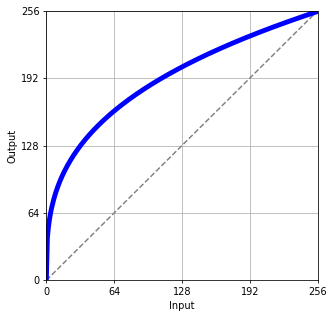

In [ ]:
#@title 🖼️ ガンマ補正のトーンカーブ
gamma = 3.0
x = np.arange(256)
y = 255*(x/255)**(1/gamma)
y = np.clip(y,0,255)
fig, ax = plt.subplots(dpi=70, figsize=(5, 5))
ax.plot(x, x, color='gray', ls='--')
ax.plot(x, y, color='b', lw=5)
ax.set(**plot_config)
ax.grid()

トーンカーブを読み解いてみましょう。

- 変換前（Input）の画素値 0 と 255 は、変換後（Output）もそれぞれ 0 と 255 で変わりません。
- 変換前の画素値 64 と 192 を比べてみると、64 の方が変換後の値の増加量が大きいです。したがって、もともと明るい画素よりも暗い画素の方が、明るさの増す量が大きいと言えます。
- グラフは単調増加であり、明るさが途中で反転することはありません。



$\gamma$の値を変えることで、このトーンカーブがどのように変わるのかを見てみましょう。  
次のコードを実行して、スライダで$\gamma$の値を変えてみてください。

In [ ]:
#@title ⌨ ガンマ補正のトーンカーブ
x = np.arange(0,256)
@interact(gamma = FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='γ')) # スライダの設定
def transform_image(gamma):
  y = 255*(x/255)**(1/gamma)
  fig, ax = plt.subplots(dpi=70, figsize=(5, 5))
  ax.plot(x, x, color='gray', ls='--')
  ax.plot(x, y, color='b', lw=5)
  ax.set(**plot_config)
  ax.grid()

$\gamma>1$のとき、画像を明るくするトーンカーブになり、$\gamma<1$のとき、画像を暗くするトーンカーブになることを確かめてください。

##S字トーンカーブ



別のトーンカーブを見てみましょう。

S字トーンカーブは、下の図のようにSの字型をしたグラフになります。  
特徴として、中間あたりの画素値の明るさの幅を広げる働きがあり、明るい画素はより明るく、暗い画素はより暗くなります。これをコントラスト強調と言います。

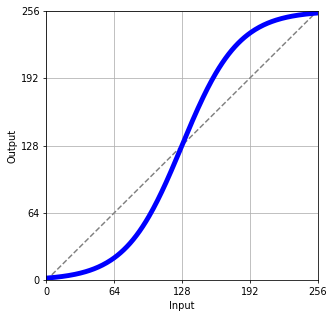

In [ ]:
#@title 🖼️ S字トーンカーブ
a = 1.2
x = np.arange(0,256)
xx = (x-128)/32
y = 1/(1+np.exp(-a*xx)) # シグモイド関数
y = y*256
fig, ax = plt.subplots(dpi=70, figsize=(5, 5))
ax.plot(x, x, color='gray', ls='--')
ax.plot(x, y, color='b', lw=5)
ax.set(**plot_config)
ax.grid()

このS字トーンカーブは、シグモイド関数
$$f(x)=\frac{1}{1+e^{-ax}}$$
を利用して作っています。

パラメータ $a$ の値によって形を変えられます。  
次のコードを実行して、$a$ の値によってトーンカーブがどのように変わるか試してみましょう。


In [ ]:
#@title ⌨ S字トーンカーブ
x = np.arange(0,256)
xx = (x-128)/32
@interact(a = FloatSlider(min=0.0, max=5.0, step=0.1, value=1.0, description='a')) # スライダの設定
def transform_image(a):
  y = 1/(1+np.exp(-a*xx)) # シグモイド関数
  y = y*256
  fig, ax = plt.subplots(dpi=70, figsize=(5, 5))
  ax.plot(x, x, color='gray', ls='--')
  ax.plot(x, y, color='b', lw=5)
  ax.set(**plot_config)
  ax.grid()

実際に画像を変換してみましょう。次のコードを実行してください。  
スライダでパラメータ$a$の値を設定できます。

In [ ]:
#@title ⌨ 画像のコントラストの変換
src = cv2.imread('okayamajo.jpg').astype(float)
x = (src-128)/32
@interact(a = FloatSlider(min=0, max=2, step=0.1, value=1.0, description='a')) # スライダの設定
def transform_image(a):
  dst = 1/(1+np.exp(-a*x))*256 # シグモイド関数を利用
  show_image(np.concatenate([dst, src], 1)) # 左にdstの画像、右にsrcの画像を表示する

$a$の値を大きくすると画像のコントラストが高くなって、もとの画像の黒いところはより黒く、白いところはより白くなっているのが分かりますか？


##ポスタリゼーション

今度は、ポスタリゼーションという変換を見てみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ ポスタリゼーション
step = 4
src = cv2.imread('asagao.png').astype('float')
dst = (src//(256//step))*(256//(step-1))
show_image(dst)

色数が少ない、イラスト調の画像ができました。

コードの3行目に書かれている明るさの計算式が複雑で、どんな計算をしているのか分かりにくいですね。  
トーンカーブのグラフにして見てみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ ポスタリゼーションのトーンカーブ
step = 4
x = np.arange(256)
y = (x//(256//step))*(256//(step-1))
y = np.clip(y,0,255)
fig, ax = plt.subplots(dpi=70, figsize=(5, 5))
ax.plot(x, y, color='b', lw=5)
ax.set(**plot_config)
ax.grid()

階段状のグラフになりました。階段の段数は4段です。  
つまり、もとの画素値は 256 階調ですが、変換後は、4 階調にまで減らされているということが分かります。

### ✍ 実践問題 3

次のコードの1行目の`step`の値で、変換後の画素値の段階数が設定できます。

`step`の値を変えて、画像の変化を見てみましょう。

1. step = 2 にしてみよう。
1. step = 8 にしてみよう。
1. step = 2 のとき、表示できる色数は最大何色になりますか？
1. step = 8 のとき、表示できる色数は最大何色になりますか？

<details><summary>答え</summary>

- step = 2 のとき、画素値は 0 か 255 のどちらかの2段階になります。赤、緑、青のそれぞれのチャンネルが2段階ずつになるので、色数は $2\times 2\times 2 = 8$ 色になります。（黒、赤、緑、青、黄、シアン、マゼンタ、白）
- step = 8 のとき、画素値は 8 段階になるので、色数は $8\times 8\times 8 = 512$ 色になります。
</details>

In [ ]:
#@title ⌨ 実践問題用コード 3
step = 4
src = cv2.imread('asagao.png').astype('float')
dst = (src//(256//step))*(256//(step-1))
show_image(dst)

<br>

# **3．色の変換**

## セピア調変換


画像の色調を変えることで、画像の雰囲気が変わります。セピア調変換は、カラー画像を色あせたモノクロ写真のような色合いに変換します。レトロでアンティークな雰囲気になります。

次の式は、セピア調の変換式です。$(R,G,B)$がもとのカラー画像の赤、緑、青の画素値で、これをセピア調に変換したとき、$(R',G',B')$が新しい画素値になります。

$$\begin{align}
R'&=0.393R+0.769G+0.189B\\
G'&=0.349R+0.686G+0.168B\\
B'&=0.272R+0.534G+0.131B
\end{align}$$

この変換をコードで書くために、行列の計算に替えます。

$$\left(\begin{array}{c}B'\\G'\\R'\end{array}\right)=\left(\begin{array}{ccc}
0.131&0.534&0.272\\
0.168&0.686&0.349\\
0.189&0.769&0.393
\end{array}\right)\left(\begin{array}{c}B\\G\\R\end{array}\right)$$

$R, G, B$の順序が入れ替わっていますが、これは、cv2では、光の3原色は $(B,G,R)$ の順番で表すことになっているからです。


次のコードを実行して、セピア調変換を試してみましょう。

In [ ]:
#@title ⌨ セピア調変換
src = cv2.imread('flowerpark.jpg')
mat = np.array([[0.131, 0.534, 0.272],
                [0.168, 0.686, 0.349],
                [0.189, 0.769, 0.393]])
dst = cv2.transform(src, mat)
print('原画像')
show_image(src)
print('\n変換後の画像')
show_image(dst)

味のあるモノトーンの画像になりましたね。

<br>

# **4．色空間の変換**

カラー画像における一つの色は、赤色、緑色、青色の3色の合成によってできるものでした。この3色の画素値をそれぞれ $R$、$G$、$B$とすると、一つの色は、赤色の軸、緑色の軸、青色の軸の3次元空間の中の1点 $(R,G,B)$ として表すことができます。この3次元空間のことを**色空間**と言います。

色空間はほかにもあります。よく使われるものに、色相$H$、彩度$S$、明度$V$を軸にもつHSV色空間があります。



色相とは、下の図のように色の種類を表すものです。

彩度は色の鮮やかさを表し、明度は色の明るさを表します。

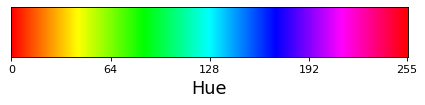

In [ ]:
#@title 🖼️ 色相
img = np.array([np.arange(256)]*32).astype('uint8')
one = np.full((32, 256), 255, 'uint8')
src = cv2.merge([img,one,one])
img = cv2.cvtColor(src, cv2.COLOR_HSV2RGB_FULL)

fig, ax = plt.subplots(dpi=80)
ax.imshow(img, vmin=0, vmax=255)
ax.tick_params(labelleft=False, left=False)
ax.set_xticks([0, 64, 128, 192, 255])
ax.set_xlabel('Hue', fontsize=16)
plt.show()

実際に画像で見てみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ RGB色空間からHSV色空間への変換
src = cv2.imread('asagao.png') # 画像を読み込む
show_image(src) # 画像を表示する
#src = cv2.resize(src, (0, 0), fx=0.6, fy=0.6)
hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV_FULL) # 色空間をRGBからHSVに変換
blue, green, red = cv2.split(src) # R,G,Bの各プレーンに分割
hue, sat, val = cv2.split(hsv)    # 色相hue,彩度sat,明度valの各プレーンに分割
print('\nRGB色空間: 赤, 緑, 青')
show_image(cv2.resize(cv2.hconcat([red, green, blue]), None, fx=0.67, fy=0.67)) # 横に並べて縮小して表示
print('\nHSV色空間: 色相, 彩度, 明度')
show_image(cv2.resize(cv2.hconcat([hue, sat, val]), None, fx=0.67, fy=0.67)) # 横に並べて縮小して表示

下の段が、それぞれ、色相、彩度、明度を画像値にして表したものです。

色相の画像（左下）を見てください。青色の色相（$H$)の値は緑色の色相の値よりも大きいので、朝顔の花の部分が葉の部分よりも大きな画素値で表示されています。  
これを利用すると、色相の範囲を定めることによって画像の特定の部分（例えば花びら）を画像から抽出することができます。

In [ ]:
#@title ⌨ 色相の範囲を指定して画像から切り出す
lower = np.array([100,   0,   0])     # 下限
upper = np.array([255, 255, 255])     # 上限
mask = cv2.inRange(hsv, lower, upper) # 切り出すためのマスク画像をつくる
dst = cv2.bitwise_and(src, src, mask=mask) # srcとマスク画像の論理積を計算
cv2_imshow(dst)

色相が$100\leq H \leq 255$の範囲を抽出してみました。花びらだけをきれいに切り出すことができましたね。

## 色相の変換

HSV色空間を使って、画素の色相を変えてみましょう。次のコードを実行すると、Hueの値をスライダーで設定できます。このHueの値を元の色相の値に加算することで色を変えます。

In [ ]:
#@title ⌨ 色相の変換
src = cv2.imread('asagao.png')
hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV_FULL)   # 色空間をRGBからHSVに変換
hue, sat, val = cv2.split(hsv)                    # 色相hue,彩度sat,明度valに分割
@interact(h=IntSlider(min=0, max=256, step=1, value=0, description='Hue'))
def transform_image(h):
  new_hue = hue + h%256                           # 色相に値を加える
  dst = cv2.merge([new_hue, sat, val])            # 色相,彩度,明度を結合して一つの画像にする
  dst = cv2.cvtColor(dst, cv2.COLOR_HSV2BGR_FULL) # RGB色空間に変換
  show_image(cv2.hconcat([dst, src]))             # 左にdstの画像、右にsrcの画像を表示

花の色が変わりましたね。

今度は彩度を変えてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨  彩度の変換
src = cv2.imread('saboten.jpg')
hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV_FULL)   # 色空間をRGBからHSVに変換
hue, sat, val = cv2.split(hsv)                    # 色相hue,彩度sat,明度valに分割
@interact(h=FloatSlider(min=0, max=5, step=0.2, value=1, description='彩度の倍率'))
def transform_image(h):
  new_sat = np.clip(sat * h, 0, 255).astype('uint8')                           # 色相に値を加える
  dst = cv2.merge([hue, new_sat, val])            # 色相,彩度,明度を結合して一つの画像にする
  dst = cv2.cvtColor(dst, cv2.COLOR_HSV2BGR_FULL) # RGB色空間に変換
  show_image(cv2.hconcat([dst, src]))             # 左にdstの画像、右にsrcの画像を表示

彩度を大きくすると色が鮮やかになり、彩度を小さくするとモノトーン（グレイスケール）に近づくことが分かりましたか?

<br>

# **5．ヒストグラム平坦化**

画像のコトントラストを高める方法には、S字トーンカーブのほかにヒストグラム平坦化（ヒストグラム均一化）があります。これを試してみましょう。

次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('fujisan.jpg', cv2.IMREAD_GRAYSCALE)
show_image(src)

この画像のヒストグラムを表示します。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像のヒストグラム
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# グラフを描画
def show_histogram_gray(hist):
  fig, ax = plt.subplots(dpi=80,figsize=(6,4))   # 描画領域のサイズを設定
  ax.plot(hist, color='k', lw=2)                 # 黒色でグラフを描画
  ax.set_xlabel('Pixel value', fontsize=12)      # x軸に名前をつける
  ax.set_ylabel('Number of pixels', fontsize=12) # y軸に名前をつける
  ax.grid()                                      # グリッド線を描く
  fig.tight_layout()                             # 余白の自動調節
show_histogram_gray(hist)

それではヒストグラム平坦化の処理を行って、画像の変化を見てみましょう。
次のコードを実行してください。

In [ ]:
#@title ⌨ ヒストグラム平坦化
def histogram_equalization(img):
    flat_img = img.flatten()    # 画像データを1次元に変換
    n = len(flat_img)
    noise = np.random.rand(n)
    flat_img = flat_img + noise       # 画素値に微小なノイズを付与
    indices = np.argsort(flat_img)    # 画素値順にソート
    new_pixelvalue = np.linspace(0, 256, n).astype(np.uint8) # 平坦化後の画素値を計算
    new_pixelvalue[-1] = 255
    dst = np.zeros(n, dtype=np.uint8) # 空の配列を用意
    dst[indices] = new_pixelvalue     # 画素値を設定
    return dst.reshape(img.shape)     # 2次元に戻す

dst = histogram_equalization(src)
print('左：変換後画像、右：原画像')
show_image(cv2.hconcat([dst, src]))
# ヒストグラムを表示
hist = cv2.calcHist([dst], [0], None, [256], [0, 256])
show_histogram_gray(hist)

左側に表示されているのがヒストグラム平坦化の処理後の画像です。その下にヒストグラムが表示されています。どの画素値も画素数が 675 になっていて、平坦化（均一化）しています。

画素値が特定の範囲に集中することなく、真っ黒の画素から真っ白までの画素まで均一に引き延ばされているので、画像の濃淡がはっきりと見えるようになります。

別の画像でも試しましょう。次のコードを実行して、画像とヒストグラムを表示してください。

In [ ]:
#@title ⌨ 画像の読み込みとヒストグラムの表示
src = cv2.imread('okayamajo.jpg', cv2.IMREAD_GRAYSCALE)
show_image(src)
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# グラフを描画
show_histogram_gray(hist)

この画像は、画素値が大きい方と小さい方の2極に偏っています。この画像をヒストグラム平坦化してみます。  
次のコードを実行してください。

In [ ]:
dst = histogram_equalization(src)
print('左：変換後画像、右：原画像')
show_image(cv2.hconcat([dst, src]))
# ヒストグラムを表示
hist = cv2.calcHist([dst], [0], None, [256], [0, 256])
show_histogram_gray(hist)

左側が変換後の画像です。空の白一色に見えていたところに明るさの濃淡が見られるようになりました。それとともに、城の壁や、手間の木々の黒いところも濃淡の差が大きくなっています。
このように、大きい画素値と小さい画素値の2極にヒストグラムが分かれているような画像でも、ヒストグラム平坦化によって画像全体のコントラストを高めることができます。

以上で、演習を終了します。

<br>

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

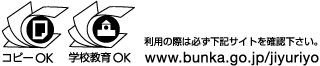  
この演習は、大学講義科目「画像工学」の講義資料として作成されています。  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この演習で使用している画像ファイル（imagefiles.zip、及び、imagefiles.zip 内の個々のファイル）については再配布を禁止します。